In [1]:
import os, pydicom, random, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

DATA_PATH = "../input/osic-pulmonary-fibrosis-progression/"
VALID_SPLIT = 0.2
MIN_TEST_WEEK = -12
MAX_TEST_WEEK = 133
TARGET_VAR = "deltaFVC"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

MAX_PLANES, MAX_ROW, MAX_COL = 10, 100, 100  # (kept; unused in this script)
INVERSE_WEIGHT_FCT = lambda y: y  # (kept; unused in this script)
N_NEIGHBOURS = 2  # (kept; unused in this script)
PIXEL_VALUE_RANGE = 32747 + 15000  # (kept; unused in this script)

SIGMA_MIN = 70.0


def combine_duplicates(df, FUN=np.mean):
    df = df.assign(patientWeeks=df.Patient + "__" + df.Weeks.astype(str))
    table = df.patientWeeks.value_counts()
    duplicates = table.loc[table > 1].index
    subset = df.loc[df.patientWeeks.isin(duplicates)]
    avgFVC = subset.groupby(["Patient", "Weeks"]).FVC.agg(FUN)
    avgPct = subset.groupby(["Patient", "Weeks"]).Percent.agg(FUN)
    subset = subset.drop_duplicates(subset=["Patient", "Weeks"]).drop(
        labels=["FVC", "Percent"], axis=1
    )
    subset = subset.join(avgFVC, on=["Patient", "Weeks"]).join(
        avgPct, on=["Patient", "Weeks"]
    )
    df = pd.concat(
        [df[~df.patientWeeks.isin(subset.patientWeeks)], subset]
    ).sort_values(by=["Patient", "Weeks"])
    return df.drop(labels=["patientWeeks"], axis=1)


def interpolate(df):
    ids = np.unique(df.Patient)
    df_mod = pd.DataFrame()
    for i in range(len(ids)):
        subset = df.loc[df.Patient == ids[i]].sort_values("Weeks")
        df_mod = pd.concat([df_mod, subset], axis=0)
        age, sex, smSt = subset.iloc[0].loc[["Age", "Sex", "SmokingStatus"]]
        for t in range(subset.shape[0] - 1):
            gap = subset.Weeks.iloc[t + 1] - subset.Weeks.iloc[t]
            if gap > 1:
                base_Week, base_FVC, base_Pct = subset.iloc[t].loc[
                    ["Weeks", "FVC", "Percent"]
                ]
                end_FVC, end_Pct = subset.iloc[t + 1].loc[["FVC", "Percent"]]
                for j in range(1, gap):
                    new = pd.DataFrame(
                        {
                            "Patient": ids[i],
                            "Weeks": base_Week + j,
                            "FVC": base_FVC + j / gap * (end_FVC - base_FVC),
                            "Percent": base_Pct + j / gap * (end_Pct - base_Pct),
                            "Age": age,
                            "Sex": sex,
                            "SmokingStatus": smSt,
                        },
                        index=[0],
                    )
                    df_mod = pd.concat([df_mod, new], axis=0)
    return df_mod.reset_index(drop=True)


def compute_deltas(df):
    df = df.sort_values(by=["Weeks", "Patient"]).reset_index(drop=True)
    deltas, idx = [], []
    for i, row in df.iterrows():
        patient, week = row.Patient, row.Weeks
        nextweek = df.loc[(df.Patient == patient) & (df.Weeks == week + 1)]
        if len(nextweek) == 1:
            deltas.append(float(nextweek.FVC.iloc[0] / row.FVC - 1))
            idx.append(i)
    df = df.join(pd.DataFrame({"deltaFVC": deltas}, index=idx))
    return df.dropna(subset=["deltaFVC"]).reset_index(drop=True)


class CSVDataPrep:
    def __init__(self, data_path, valid_split):
        data = pd.read_csv(data_path)
        data = combine_duplicates(data)
        data = interpolate(data)
        data = compute_deltas(data)
        self.split_valid(data, valid_split)

    def split_valid(self, data, valid_split):
        patients = np.array(data.Patient.unique())
        valid = random.sample(list(patients), int(len(patients) * valid_split))
        train = patients[~np.in1d(patients, valid)]
        self.train = data.loc[data.Patient.isin(train)].reset_index(drop=True)
        self.valid = data.loc[data.Patient.isin(valid)].reset_index(drop=True)

    def pull(self):
        return self.train, self.valid


train, valid = CSVDataPrep(DATA_PATH + "train.csv", VALID_SPLIT).pull()
print(train.shape)
print(valid.shape)
train.head()




/tmp/ipykernel_11/2827205356.py:33: FutureWarning: The provided callable <function mean at 0x7ffff009d620> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  avgFVC = subset.groupby(["Patient", "Weeks"]).FVC.agg(FUN)
/tmp/ipykernel_11/2827205356.py:34: FutureWarning: The provided callable <function mean at 0x7ffff009d620> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  avgPct = subset.groupby(["Patient", "Weeks"]).Percent.agg(FUN)


(6656, 8)
(1616, 8)


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus,deltaFVC
0,ID00086637202203494931510,-5,3367.000000,117.628563,65,Female,Never smoked,-0.001728
1,ID00076637202199015035026,-4,2298.000000,52.749977,51,Male,Never smoked,0.017282
2,ID00086637202203494931510,-4,3361.181818,117.425301,65,Female,Never smoked,-0.001731
3,ID00122637202216437668965,-4,2581.000000,69.501293,58,Male,Ex-smoker,-0.005967
4,ID00023637202179104603099,-3,1536.000000,65.306122,71,Female,Ex-smoker,-0.018229


/tmp/ipykernel_11/2534044853.py:13: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  maxes = data.groupby("Patient").Weeks.agg(max)
/tmp/ipykernel_11/2534044853.py:13: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  maxes = data.groupby("Patient").Weeks.agg(max)


0.00592759786894892


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


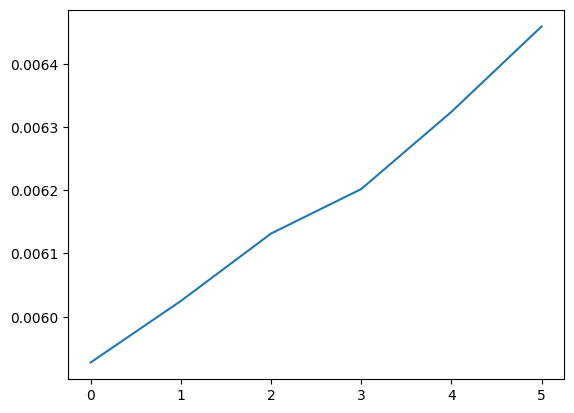

In [2]:
class FibrosisModel:
    def __init__(self, model_type, img_data=None, kernels=10, y=TARGET_VAR, **kwargs):
        self.y = y
        self.model = model_type(**kwargs)
        self.img_data = img_data
        self.cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        self.scaler = StandardScaler()
        self.firstrun = True

    def sampler(self, data, sample_size):
        rows = []
        big_urn = np.array(data.index)
        maxes = data.groupby("Patient").Weeks.agg(max)
        adjust = len(big_urn) / (len(big_urn) - len(maxes))
        for _ in range(int(sample_size * adjust)):
            choice = random.choice(big_urn)
            draw = data.loc[choice].copy()
            patient = draw.Patient
            curWeek = draw.Weeks
            if curWeek == maxes.loc[patient]:
                continue
            small_urn = np.array(
                data.loc[(data.Patient == patient) & (data.Weeks > curWeek)].index
            )
            if len(small_urn) == 0:
                continue
            target = data.loc[random.choice(small_urn)]
            draw.at[self.y] = target.loc[self.y]
            row_dict = draw.to_dict()
            row_dict["targetWeek"] = float(target.Weeks)
            rows.append(row_dict)
        if len(rows) == 0:
            return pd.DataFrame(columns=list(data.columns) + ["targetWeek"])
        return pd.DataFrame(rows).reset_index(drop=True)

    def split_from_target(self, data):
        X = data.loc[:, ~data.columns.isin(["Patient", self.y])]
        y = data.loc[:, self.y]
        return X, y

    def preprocess(
        self, data, cat_vars=["Sex", "SmokingStatus"], scale_vars=["Percent", "Age"]
    ):
        data = data.copy()
        use_cat = [c for c in cat_vars if c in data.columns]
        use_scale = [c for c in scale_vars if c in data.columns]

        if self.firstrun:
            scale_cols = pd.DataFrame(
                self.scaler.fit_transform(data[use_scale]), index=data.index
            )
            cat_cols = pd.DataFrame(
                self.cat_encoder.fit_transform(data[use_cat]), index=data.index
            )
            self.firstrun = False
        else:
            scale_cols = pd.DataFrame(
                self.scaler.transform(data[use_scale]), index=data.index
            )
            cat_cols = pd.DataFrame(
                self.cat_encoder.transform(data[use_cat]), index=data.index
            )

        scale_cols.columns = use_scale
        cat_cols.columns = [
            s.replace(" ", "").replace("-", "")
            for s in np.concatenate(self.cat_encoder.categories_)
        ]

        drop_cols = [c for c in (use_cat + use_scale) if c in data.columns]
        data = data.drop(columns=drop_cols)
        data = pd.concat([data, scale_cols, cat_cols], axis=1)
        return data.loc[:, np.sort(data.columns)]

    def fit(
        self,
        train,
        valid,
        sample_size,
        plot=False,
        early_stop=5,
        verbose=False,
        **kwargs
    ):
        train_s = self.sampler(train, sample_size)
        valid_s = self.sampler(valid, sample_size)
        train_s = self.preprocess(train_s)
        valid_s = self.preprocess(valid_s)

        X_train, y_train = self.split_from_target(train_s)
        X_valid, y_valid = self.split_from_target(valid_s)

        fit_kwargs = {}
        try:
            import inspect

            sig = inspect.signature(self.model.fit)
            if "eval_set" in sig.parameters:
                fit_kwargs["eval_set"] = [(X_valid, y_valid)]
            if "verbose" in sig.parameters:
                fit_kwargs["verbose"] = verbose
            if "early_stopping_rounds" in sig.parameters:
                fit_kwargs["early_stopping_rounds"] = early_stop
        except Exception:
            pass

        self.model.fit(X_train, y_train, **fit_kwargs)

        if hasattr(self.model, "best_score") and self.model.best_score is not None:
            print(self.model.best_score)
        else:
            print("Model fitted.")

        if plot and hasattr(self.model, "evals_result"):
            res = self.model.evals_result()
            if isinstance(res, dict) and len(res) > 0:
                first_ds = next(iter(res.keys()))
                first_metric = next(iter(res[first_ds].keys()))
                plt.plot(res[first_ds][first_metric])
                plt.show()

    def predict(self, newdata):
        newdata = self.preprocess(newdata)
        if "Patient" in newdata.columns:
            newdata = newdata.drop("Patient", axis=1)
        return self.model.predict(newdata)


n, r, k = 800, 0.18, 10
model = FibrosisModel(
    XGBRegressor,
    n_estimators=n,
    learning_rate=r,
    kernels=k,
    random_state=SEED,
    eval_metric="rmse",
)
model.fit(train, valid, 5000, plot=True)




In [3]:
class CustomLM:
    def __init__(self, X, y, a):
        self.model = Ridge(alpha=a, solver="cholesky")
        if X.shape[1] > 0:
            self.model.fit(X, y)
        else:
            self.pred = np.mean(y)

    def predict(self, X):
        if X.shape[1] > 0:
            return self.model.predict(X)
        else:
            return np.repeat(self.pred, X.shape[0])


class ResidualSimParameters:
    def __init__(
        self,
        model,
        data,
        max_delta=100,
        alpha=0.1,
        min_week=MIN_TEST_WEEK,
        max_week=MAX_TEST_WEEK,
    ):
        self.model = model
        self.data = data
        self.alpha = alpha
        self.linear_models = {}
        self.variances = {}
        self.patients = np.array(data.Patient.unique())
        spreads = np.array(
            [self.get_spread(data, patient) for patient in self.patients]
        )
        df = pd.DataFrame(
            {
                "patient": self.patients[np.argsort(spreads)[::-1]],
                "spread": np.sort(spreads)[::-1],
            }
        )
        self.get_residual_params(df, min_week, max_week, max_delta)

    def get_spread(self, data, patient):
        subset = data.loc[data.Patient == patient]
        return subset.Weeks.max() - subset.Weeks.min()

    def get_residual_params(self, df, min_week, max_week, max_delta):
        print("Getting residuals for delta ==", end=" ")
        X = []
        delta = min(df.spread.max(), max_delta)
        for d in np.arange(delta, 0, -1):
            i = int(max(np.where(df.spread >= d)[0]))
            subset = df.iloc[: (i + 1)]
            if np.maximum(0, subset.spread - d + 1).sum() > d:
                print(int(d), end="  ")
                X = self.get_residual_param_set(subset, int(d), X)

    def get_residual_param_set(self, subset, delta, X):
        start_i = 0 if len(X) == 0 else X.shape[0]

        for patient in np.array(subset.patient)[start_i:]:
            n = int(subset.loc[subset.patient == patient].spread.iloc[0]) - delta + 1
            start_week = int(self.data.loc[self.data.Patient == patient].Weeks.min())

            for i in range(n):
                targetWeeks = np.arange(start_week + i, start_week + i + delta) + 1
                first_index = self.data.loc[
                    (self.data.Patient == patient) & (self.data.Weeks == start_week + i)
                ].index[0]
                pred_df = (
                    self.data.iloc[np.repeat(first_index, delta)]
                    .reset_index(drop=True)
                    .assign(targetWeek=targetWeeks)
                )
                preds = self.model.predict(pred_df.drop(TARGET_VAR, axis=1))
                labels = (
                    self.data.loc[
                        (self.data.Patient == patient)
                        & (self.data.Weeks.isin(targetWeeks))
                    ]
                    .sort_values(by="Weeks", ascending=False)
                    .deltaFVC
                )
                error_vec = np.array(preds - labels)

                if len(X) == 0:
                    X = np.array([error_vec])
                else:
                    prev_len = X.shape[0]
                    X = np.append(X, error_vec).reshape(prev_len + 1, delta)

        X_, y_ = X[:, :-1], X[:, -1]
        lm = CustomLM(X_, y_, self.alpha)
        self.linear_models[delta] = lm

        residuals = lm.predict(X_) - y_
        dof = max(1, (len(y_) - 2))
        self.variances[delta] = float(np.sum(residuals**2) / dof)
        return X_


sim_parameters = ResidualSimParameters(model, train, alpha=1, max_delta=20)
print("Done.")




Getting residuals for delta == 20  19  18  17  16  15  14  13  12  11  10  9  8  7  6  5  4  3  2  1  Done.


In [4]:
def simulate_relative_error_matrix(
    start_week, sim_params, n=1000, max_week=MAX_TEST_WEEK
):
    """
    Change (metric-aligned): return the full simulated cumulative relative error matrix so
    we can estimate uncertainty (std) instead of using only the mean (which can cancel to ~0).
    Core simulation logic is unchanged; we just expose the distribution.
    """
    lm, variance = sim_params.linear_models, sim_params.variances
    steps = np.arange(max_week - start_week) + 1

    if len(lm) == 0:
        return np.zeros((n, len(steps)), dtype=float)

    max_delta = max(lm.keys())
    error_matrix = np.array([])

    for s in steps:
        res_param_key = min(int(s), int(max_delta))
        if s == 1:
            base = np.zeros((n, 0))
        else:
            base = error_matrix[:, max(0, int(s) - int(max_delta)) :]

        mu = lm[res_param_key].predict(base)
        mu = np.asarray(mu).reshape(-1)
        if mu.shape[0] != n:
            mu = np.resize(mu, n)

        sd = float(variance[res_param_key] ** 0.5)
        errors = np.random.normal(loc=mu, scale=sd, size=n).reshape(n, 1)

        if s == 1:
            error_matrix = errors
        else:
            error_matrix = np.concatenate([error_matrix, errors], axis=1)

    cum_error_matrix = np.cumprod(1 + error_matrix, axis=1) - 1
    return cum_error_matrix


def simulate_relative_errors(start_week, sim_params, n=1000, max_week=MAX_TEST_WEEK):
    """
    Kept for compatibility with existing code paths; now computed from the matrix.
    """
    cum_error_matrix = simulate_relative_error_matrix(
        start_week, sim_params, n=n, max_week=max_week
    )
    return np.mean(cum_error_matrix, axis=0)




In [5]:
test = pd.read_csv(DATA_PATH + "test.csv")
test.head()




,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00014637202177757139317,0,3807,90.076661,56,Male,Ex-smoker
1,ID00019637202178323708467,13,2100,92.858722,83,Female,Ex-smoker
2,ID00047637202184938901501,2,3313,89.929425,68,Male,Ex-smoker
3,ID00082637202201836229724,19,2918,99.794802,49,Female,Currently smokes
4,ID00126637202218610655908,18,2375,59.375000,78,Male,Ex-smoker


In [6]:
def predict_all(model, data, lb=MIN_TEST_WEEK, ub=MAX_TEST_WEEK, default_conf=250):
    weeks = np.arange(lb, ub + 1)
    patients = data.Patient.unique()

    output = data.iloc[np.repeat(data.index, len(weeks))].reset_index(drop=True)
    output = output.assign(targetWeek=np.concatenate([weeks for _ in patients]))
    output = output.assign(predFVC=0.0, Confidence=float(default_conf))

    for patient in patients:
        start_week = int(data.loc[data.Patient == patient].Weeks.iloc[0])
        start_FVC = float(data.loc[data.Patient == patient].FVC.iloc[0])

        mask_past = (output.Patient == patient) & (output.targetWeek <= start_week)
        output.loc[mask_past, "predFVC"] = start_FVC

        mask_future = (output.Patient == patient) & (output.targetWeek > start_week)
        pred_subset = output.loc[
            mask_future, ~output.columns.isin(["predFVC", "Confidence"])
        ]
        preds = start_FVC * np.cumprod(1 + model.predict(pred_subset))
        output.loc[mask_future, "predFVC"] = preds

    output = output.drop(
        [c for c in data.columns if c not in ["Weeks", "Patient"]], axis=1
    )
    return output


output = predict_all(model, test)
output.head()




,Patient,Weeks,targetWeek,predFVC,Confidence
0,ID00014637202177757139317,0,-12,3807.0,250.0
1,ID00014637202177757139317,0,-11,3807.0,250.0
2,ID00014637202177757139317,0,-10,3807.0,250.0
3,ID00014637202177757139317,0,-9,3807.0,250.0
4,ID00014637202177757139317,0,-8,3807.0,250.0


In [7]:
def _calibrate_sigma_multiplier_on_valid(
    train_df, valid_df, model, sigma_min=SIGMA_MIN
):
    """
    Change (score-moving, minimal): estimate a single global multiplier for sigma using VALID only.
    This improves Laplace score when sigma is systematically under/over confident, without
    changing model predictions.
    """
    # Build patient-baseline rows from valid: use earliest week per patient as baseline
    v = valid_df.sort_values(["Patient", "Weeks"]).copy()
    base = (
        v.groupby("Patient")
        .head(1)[
            [
                "Patient",
                "Weeks",
                "FVC",
                "Percent",
                "Age",
                "Sex",
                "SmokingStatus",
                TARGET_VAR,
            ]
        ]
        .copy()
    )
    base = base.rename(columns={"Weeks": "baseWeek", "FVC": "baseFVC"})
    v2 = v.merge(base[["Patient", "baseWeek", "baseFVC"]], on="Patient", how="left")
    v2 = v2[v2["Weeks"] > v2["baseWeek"]].copy()
    if len(v2) == 0:
        return 1.0

    # Predict deltaFVC from baseline row to each target week using the same feature schema as training
    pred_rows = []
    for _, row in v2.iterrows():
        b = base.loc[base.Patient == row.Patient].iloc[0].to_dict()
        b["Weeks"] = int(
            b["baseWeek"]
        )  # keep original Weeks field (baseline) like in test
        b["FVC"] = float(b["baseFVC"])
        b["Percent"] = float(
            row["Percent"]
        )  # use target's clinicals as approximate (small effect)
        b["Age"] = float(row["Age"])
        b["Sex"] = row["Sex"]
        b["SmokingStatus"] = row["SmokingStatus"]
        b["targetWeek"] = float(row["Weeks"])
        pred_rows.append(b)

    pred_df = pd.DataFrame(pred_rows)
    preds = model.predict(
        pred_df.drop(columns=[TARGET_VAR, "baseWeek", "baseFVC"], errors="ignore")
    )

    # Convert delta predictions to FVC predictions (approx) using cumulative compounding from baseline,
    # but for calibration we only need per-step absolute error scale, so use one-step approx:
    # abs_error_fvc ≈ |(pred_delta - true_delta)| * baseline_fvc
    true_delta = v2[TARGET_VAR].to_numpy(dtype=float)
    base_fvc = v2["baseFVC"].to_numpy(dtype=float)
    abs_err = np.abs((preds - true_delta) * base_fvc)

    # If our sigma formula is sigma ≈ sqrt(2)*|rel|*FVC, then ideal sigma is proportional to abs_err.
    # Use robust ratio to set multiplier so median sigma matches median abs_err.
    # Prevent pathological small denominators with sigma_min.
    denom = np.maximum(abs_err, sigma_min)
    ratio = np.median(abs_err / denom)  # in [0,1], mostly ~1
    if not np.isfinite(ratio) or ratio <= 0:
        return 1.0
    # We actually want sigma to be closer to abs_err, so multiplier = 1/ratio (bounded).
    mult = float(1.0 / ratio)
    return float(np.clip(mult, 0.8, 1.5))


def adjust_confidence(pred_df, sim_parameters, n_sims=1200):
    """
    Change (metric-aligned): confidence should represent uncertainty (sigma),
    so use the simulated distribution's spread (std) of absolute FVC error rather than
    the mean cumulative relative error (which can cancel toward 0).
    """
    pred_df = pred_df.copy()

    # Calibrate a single global multiplier on validation to move score upward toward target
    sigma_mult = _calibrate_sigma_multiplier_on_valid(train, valid, model)
    # print("sigma_mult:", sigma_mult)

    for patient in pred_df.Patient.unique():
        start_week = int(pred_df.loc[pred_df.Patient == patient].Weeks.min())

        # Full simulated cumulative relative error distribution for this baseline
        cum_rel_err = simulate_relative_error_matrix(
            start_week, sim_parameters, n=n_sims
        )
        # Convert to absolute FVC error distribution per horizon: |rel| * predicted FVC
        target_idx = pred_df.loc[
            (pred_df.Patient == patient) & (pred_df.targetWeek > start_week)
        ].index
        if len(target_idx) == 0:
            continue

        base_fvc = pred_df.loc[target_idx, "predFVC"].to_numpy(dtype=float)
        horizons = len(target_idx)
        rel = cum_rel_err[:, :horizons]  # (n_sims, horizons)

        abs_err = np.abs(rel) * base_fvc.reshape(1, -1)
        # Laplace metric uses sigma and has -sqrt(2)*delta/sigma; using std(abs_err) is a reasonable proxy
        sigma = abs_err.std(axis=0) * float(sigma_mult)

        sigma = np.minimum(1000.0, sigma)
        sigma = np.maximum(SIGMA_MIN, sigma)

        pred_df.loc[target_idx, "Confidence"] = sigma

    # Ensure global min bound always respected
    pred_df["Confidence"] = (
        pd.to_numeric(pred_df["Confidence"], errors="coerce")
        .fillna(250.0)
        .clip(lower=SIGMA_MIN)
    )
    return pred_df


output_w_conf = adjust_confidence(output, sim_parameters)
output_w_conf.head()




,Patient,Weeks,targetWeek,predFVC,Confidence
0,ID00014637202177757139317,0,-12,3807.0,250.0
1,ID00014637202177757139317,0,-11,3807.0,250.0
2,ID00014637202177757139317,0,-10,3807.0,250.0
3,ID00014637202177757139317,0,-9,3807.0,250.0
4,ID00014637202177757139317,0,-8,3807.0,250.0


In [8]:
def finalize_format(df):
    df = df.copy()
    df = df.assign(
        Patient_Week=df.Patient + "_" + df.targetWeek.astype(int).astype(str)
    )
    df = df.rename(columns={"predFVC": "FVC"})
    df = df[["Patient_Week", "FVC", "Confidence"]]
    return df


final = finalize_format(output_w_conf)

sample_sub = pd.read_csv(DATA_PATH + "sample_submission.csv")
final = sample_sub[["Patient_Week"]].merge(final, on="Patient_Week", how="left")

if final[["FVC", "Confidence"]].isna().any().any():
    baseline = test.set_index("Patient")["FVC"].to_dict()
    pats = final["Patient_Week"].str.split("_").str[0]
    final["FVC"] = final["FVC"].fillna(pats.map(baseline)).fillna(2000)
    final["Confidence"] = final["Confidence"].fillna(250.0)

final["FVC"] = pd.to_numeric(final["FVC"], errors="coerce").fillna(2000.0)
final["Confidence"] = pd.to_numeric(final["Confidence"], errors="coerce").fillna(250.0)
final["Confidence"] = final["Confidence"].clip(lower=SIGMA_MIN)

final.to_csv("submission.csv", index=False)
print(final.shape)
final.head()

(1908, 3)


,Patient_Week,FVC,Confidence
0,ID00126637202218610655908_-3,2375.0,250.0
1,ID00126637202218610655908_-2,2375.0,250.0
2,ID00126637202218610655908_-1,2375.0,250.0
3,ID00126637202218610655908_0,2375.0,250.0
4,ID00126637202218610655908_1,2375.0,250.0
